In [1]:
from nltk.test.unit.lm.test_models import training_data
from tqdm import tqdm
from analysis.nlp_transformations import separate_previous_conversation, remove_footers
from typing import List
from dao.lab_report import DAOLabReport

from dao.attribute import DAOAttributePL

from models.attribute import AttributePL, AttributePLInDB

from ml.model_training import evaluate_models, k_fold_cross_validation
from ml.data_preparation import convert_db_attributes_to_input_data
from typing import List
from analysis.nlp_transformations import replace_links_with_text
from ml.data_preparation import find_significant_features
from notebooks.ananas_ml import selected_features

In [2]:
dao_attribute: DAOAttributePL = DAOAttributePL('attributes_reference', db_name="ananas_prod")

real: List[AttributePLInDB] = dao_attribute.find_many_by_query({"is_generated": False})

generated_gpt4: List[AttributePLInDB] = dao_attribute.find_many_by_query({"is_generated": True, 'llm_model_name': "gpt-4o-mini"})
generated_gpt5: List[AttributePLInDB] = dao_attribute.find_many_by_query({"is_generated": True, 'llm_model_name': "gpt-5"})
generated_deepseek: List[AttributePLInDB] = dao_attribute.find_many_by_query({"is_generated": True, 'llm_model_name': "deepseek-chat-v3-0324"})
generated_claude: List[AttributePLInDB] = dao_attribute.find_many_by_query({"is_generated": True, 'llm_model_name': "claude-3.5-haiku"})

generated: List[AttributePLInDB] = generated_gpt4 + generated_gpt5 + generated_deepseek + generated_claude

In [3]:
generated_flat_dict = [(x.to_flat_dict_normalized(), 1) for x in generated]
real_flat_dict = [(x.to_flat_dict_normalized(), 0) for x in real]

In [4]:
data = [(x.to_flat_dict_normalized(), 1) for x in generated]
data += [(x.to_flat_dict_normalized(), 0) for x in real]
# replace None with 0
for i in range(len(data)):
    for key in data[i][0].keys():
        if data[i][0][key] is None:
            data[i][0][key] = 0

significant_features = find_significant_features(data)

In [5]:
significant_features

['stylometrix_metrics.syntactic.SY_S_NOM',
 'number_of_errors',
 'combination_features.partial_attribute_statistics.standard_deviation_sentence_word_length.average',
 'stylometrix_metrics.syntactic.SY_S_DE',
 'combination_features.partial_attribute_statistics.number_of_errors.average',
 'combination_features.partial_attribute_statistics.variance_sentence_word_length.average',
 'variance_sentence_word_length',
 'standard_deviation_sentence_word_length',
 'stylometrix_metrics.lexical.L_SYL_G4',
 'combination_features.partial_attribute_statistics.variance_sentence_char_length.average',
 'stylometrix_metrics.inflection.IN_V_ACT',
 'combination_features.partial_attribute_statistics.standard_deviation_sentence_char_length.average',
 'text_errors_by_category.PUNCTUATION',
 'stylometrix_metrics.inflection.IN_N_4ACC',
 'variance_sentence_char_length',
 'standard_deviation_sentence_char_length',
 'average_word_char_length',
 'combination_features.partial_attribute_statistics.variance_sentence_wo

In [6]:
from matplotlib import pyplot as plt
import numpy as np


def hist_attribute(data, title, num_bin = 21, max_value=5, min_value=0, metric_name="Metric", top=0.5, file_name=""):
    data_to_plot = []
    for d in data:
        if d<max_value:
            data_to_plot.append(d)
        else:
            data_to_plot.append(max_value)

    w = (max_value-min_value)/num_bin
    weights = np.ones_like(data_to_plot) / len(data_to_plot)
    plt.hist(data_to_plot, bins=np.arange(min_value, max_value + w, w), weights=weights)
    plt.title(title)
    plt.xlim([min_value, max_value])
    plt.ylim(top=top)
    plt.xlabel(f'{metric_name} value')
    plt.ylabel('Lab reports share')
    # plt.xticks([i for i in range(min_value, max_value+1, 2)])
    plt.savefig(f'../images/{file_name}.png')
    plt.show()

def plot_two_hists(data1, data2, title, metric_name="Metric", num_bin=21, min_value=0, max_value=5, top=0.5, additional_values=None):
    # Truncate data to max_value if needed
    data1_to_plot = [d if d < max_value else max_value for d in data1]
    data2_to_plot = [d if d < max_value else max_value for d in data2]

    w = (max_value - min_value) / num_bin
    bins = np.arange(min_value, max_value + w, w)
    
    weights1 = np.ones_like(data1_to_plot) / len(data1_to_plot)
    weights2 = np.ones_like(data2_to_plot) / len(data2_to_plot)
    
    plt.hist(data1_to_plot, bins=bins, weights=weights1, alpha=0.7, label='Generated', color='red')
    plt.hist(data2_to_plot, bins=bins, weights=weights2, alpha=0.7, label='Real', color='blue')
    if additional_values is not None:
        if len(additional_values) == 2:
            plt.axvline(additional_values[0], color='red', linestyle='--', linewidth=1, label='Generated sample')
            plt.axvline(additional_values[1], color='blue', linestyle='--', linewidth=1, label='Real sample')
        elif len(additional_values) == 4:
            plt.axvline(additional_values[0], color='red', linestyle='--', linewidth=1, label='Generated sample 1')
            plt.axvline(additional_values[1], color='orange', linestyle='--', linewidth=1, label='Generated sample 2')
            plt.axvline(additional_values[2], color='blue', linestyle='--', linewidth=1, label='Real sample 1')
            plt.axvline(additional_values[3], color='green', linestyle='--', linewidth=1, label='Real sample 2')
    #plt.title(title)
    plt.xlim([min_value, max_value])
    plt.ylim(top=top)
    plt.xlabel(f'{metric_name} value')
    plt.ylabel('Lab reports share')
    plt.legend()
    plt.show()
    
def compare_2_hists(attribute_name: str, min_value=None, max_value=None, top=0.41, num_bin = 21, one_hist=True, additional_values=None):
    data_gen = [attribute[0][attribute_name] for attribute in generated_flat_dict]
    data_real = [attribute[0][attribute_name] for attribute in real_flat_dict]
    if min_value is None:
        min_value = min(np.percentile(data_gen, 5), np.percentile(data_real, 5))
    if max_value is None:
        max_value = max(np.percentile(data_gen, 95), np.percentile(data_real, 95))
    
    if not one_hist:
        hist_attribute(data_gen, f'Generated lab reports', min_value=min_value, max_value=max_value, metric_name=attribute_name, top=top, num_bin=num_bin, file_name=f"{attribute_name}_gen")
        hist_attribute(data_real, f'Real lab reports', min_value=min_value, max_value=max_value, metric_name=attribute_name, top=top, num_bin=num_bin, file_name=f"{attribute_name}_rel")
    else:
        plot_two_hists(data_gen, data_real, f'Generated vs Real lab reports', metric_name=attribute_name, min_value=min_value, max_value=max_value, top=top, num_bin=num_bin, additional_values=additional_values)

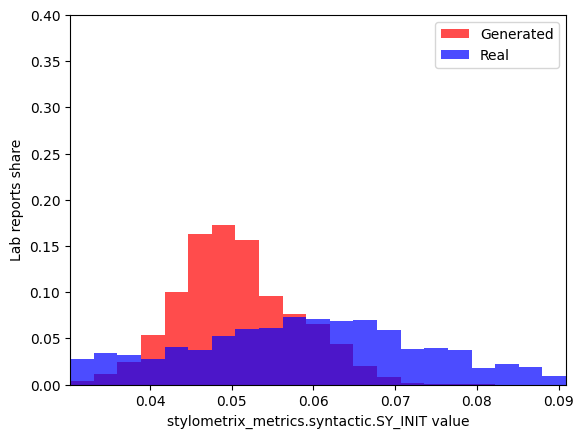

In [25]:
for feature in significant_features[:1]:
    compare_2_hists('stylometrix_metrics.syntactic.SY_INIT', top=0.4)

In [14]:
from scipy.stats import percentileofscore
from api.api_models.lightbulb_score import LightbulbScoreType


def boost_with_cosine(score, boost=1.7, power=0.7):
    """
    Multiply by a smooth cosine bump centered at 0.
    - boost sets multiplier at 0.
    - power < 1 makes growth faster near 0.
    """
    s = float(np.clip(score, -1.0, 1.0))
    base = 0.5 * (1.0 + np.cos(np.pi * s))  # 1 at 0, 0 at ±1
    shaped = base ** power                  # adjust growth
    m = 1.0 + (boost - 1.0) * shaped
    return float(np.clip(s * m, -1.0, 1.0))

def _relative_percentile_score(value: float,real_values: np.ndarray,gen_values: np.ndarray, category: LightbulbScoreType):

    real_percentile = percentileofscore(real_values, value, kind="weak")/100.0
    real_median = np.median(real_values)
    gen_percentile = percentileofscore(gen_values, value, kind="weak")/100.0
    gen_median = np.median(gen_values)

    if category == LightbulbScoreType.HUMAN_WRITTEN:
        real_score = ((-abs(real_percentile - 0.5))*2)+1
        return boost_with_cosine(real_score)
    elif category == LightbulbScoreType.LLM_GENERATED:
        gen_score = (abs(gen_percentile - 0.5)-0.5)*2
        return boost_with_cosine(gen_score)
    else:
        real_score = real_percentile - 0.5
        gen_score = gen_percentile - 0.5
        result = real_score + gen_score
        if real_median < gen_median:
            result = -result

        return boost_with_cosine(result)

In [7]:
from api.api_models.document import Document, DocumentInDB
from dao.base import DAOBase
from config import MONGO_CLIENT


class DAODocument(DAOBase):
    def __init__(self, collection_name="documents"):
        super().__init__(MONGO_CLIENT,
                         "ananas_prod",
                         collection_name,
                         Document,
                         DocumentInDB)

In [20]:
dao_attributes_to_compare: DAOAttributePL = DAOAttributePL('attributes', db_name="ananas_prod")
dao_document = DAODocument()
attributes_to_compare: List[AttributePLInDB] = dao_attributes_to_compare.find_all()
generated_samples = []
human_samples = []
other_samples = []
for attribute in attributes_to_compare:
    doc_id = attribute.referenced_doc_id
    document = dao_document.find_by_id(doc_id)
    if "gen" in document.document_name.lower() and "api" not in document.document_name.lower():
        generated_samples.append((document.document_name, attribute))
    elif "human" in document.document_name.lower():
        human_samples.append((document.document_name, attribute))
    else:
        other_samples.append((document.document_name, attribute))

In [10]:
training_data = [(x.to_flat_dict_normalized(exclude=significant_features[70:]), 1) for x in generated]
training_data += [(x.to_flat_dict_normalized(exclude=significant_features[70:]), 0) for x in real]
# replace None with 0
for i in range(len(training_data)):
    for key in training_data[i][0].keys():
        if training_data[i][0][key] is None:
            training_data[i][0][key] = 0


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier

In [13]:
def compare_models(dataset):
    models = {
        'Decision Tree': DecisionTreeClassifier(),
        'Random Forest': RandomForestClassifier(),
        'CatBoost': CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
    }
    for model_name, model in models.items():
        results = k_fold_cross_validation(model, dataset, 10)
        print(f"{model_name} & {round(results['accuracy'], 4)} & {round(results['precision'], 4)} & {round(results['recall'], 4)} & {round(results['f1_score'], 4)} & {round(results['roc_auc'], 4)}")
        print(results)
        print("\n")

In [14]:
compare_models(training_data)

Decision Tree & 0.9798 & 0.9871 & 0.9873 & 0.9872 & 0.9695
{'accuracy': 0.9797775507855618, 'precision': 0.9870637890337512, 'recall': 0.9872568278418681, 'f1_score': 0.9871560352274151, 'roc_auc': 0.9695447847679525, 'TP': 923.0, 'TN': 239.8, 'FP': 12.1, 'FN': 11.9}


Random Forest & 0.9919 & 0.993 & 0.9968 & 0.9949 & 0.9995
{'accuracy': 0.9919114607233223, 'precision': 0.9929676326140745, 'recall': 0.9967885565024515, 'f1_score': 0.9948736169406388, 'roc_auc': 0.9994996645291332, 'TP': 931.9, 'TN': 245.3, 'FP': 6.6, 'FN': 3.0}


MLP Classifier & 0.7488 & 0.8834 & 0.7919 & 0.8049 & 0.6952
{'accuracy': 0.7487915032299035, 'precision': 0.8834087186187499, 'recall': 0.7918985903191949, 'f1_score': 0.8049468189510469, 'roc_auc': 0.6952144382436495, 'TP': 740.0, 'TN': 148.7, 'FP': 103.2, 'FN': 194.9}


CatBoost & 0.9955 & 0.9963 & 0.998 & 0.9971 & 0.9998
{'accuracy': 0.9954500057537317, 'precision': 0.9962561591750461, 'recall': 0.9979618745782336, 'f1_score': 0.9971073739860665, 'roc_auc'

In [96]:
selected_features = [
#"stylometrix_metrics.syntactic.SY_S_NOM",
"number_of_errors",
#"stylometrix_metrics.syntactic.SY_S_DE",
"standard_deviation_sentence_word_length",
"stylometrix_metrics.lexical.L_SYL_G4",
"stylometrix_metrics.inflection.IN_V_ACT",
"text_errors_by_category.PUNCTUATION",
"stylometrix_metrics.inflection.IN_N_4ACC",
"average_word_char_length",
"stylometrix_metrics.inflection.IN_V_PAST",
"burstiness2",
"stylometrix_metrics.inflection.IN_N_2GEN",
"stylometrix_metrics.syntactic.SY_INIT",
]

In [97]:
from ml.data_preparation import convert_db_to_attributes_selected_features

training_data = convert_db_to_attributes_selected_features(generated, real, selected_features)

In [98]:
from sklearn.feature_extraction import DictVectorizer
import numpy as np

catboost_model = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=6, verbose=0)
vectorizer = DictVectorizer(sparse=False)
features = vectorizer.fit_transform([features for features, _ in training_data])
labels = np.array([label for _, label in training_data])

catboost_model.fit(features, labels)

# Feature importance

In [99]:
feature_names = vectorizer.get_feature_names_out()
importances = catboost_model.get_feature_importance()
for name, imp in sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {imp:.4f}")

text_errors_by_category.PUNCTUATION: 17.4988
stylometrix_metrics.syntactic.SY_INIT: 16.5317
standard_deviation_sentence_word_length: 15.7738
stylometrix_metrics.inflection.IN_V_ACT: 10.3594
stylometrix_metrics.inflection.IN_V_PAST: 7.2351
number_of_errors: 7.0240
stylometrix_metrics.lexical.L_SYL_G4: 6.4924
stylometrix_metrics.inflection.IN_N_4ACC: 5.3390
average_word_char_length: 5.0950
burstiness2: 4.8361
stylometrix_metrics.inflection.IN_N_2GEN: 3.8146


# Sample prediction

In [100]:
from ml.model_validation import calculate_classification_metrics

generated_samples_no_names = [x[1] for x in generated_samples]
human_samples_no_names = [x[1] for x in human_samples]

test_data = convert_db_to_attributes_selected_features(generated_samples_no_names, human_samples_no_names, selected_features)

test_features = vectorizer.transform([f for f, _ in test_data])
test_labels = np.array([label for _, label in test_data])

# Get predictions and probabilities
predicted_labels = catboost_model.predict(test_features)
predicted_probs = catboost_model.predict_proba(test_features)[:, 1]  # probability of positive class

# Calculate metrics
results = calculate_classification_metrics(test_labels, predicted_labels, predicted_probs)

# Show results
for metric, value in results.items():
    print(f"{metric}: {value:.4f}" if isinstance(value, float) else f"{metric}: {value}")

accuracy: 0.7941
precision: 1.0000
recall: 0.5333
f1_score: 0.6957
roc_auc: 0.9193
TP: 8
TN: 19
FP: 0
FN: 7


In [101]:
predicted_probs

array([0.21331097, 0.51514971, 0.99779654, 0.93544309, 0.9436099 ,
       0.00606644, 0.72370736, 0.0307592 , 0.68387971, 0.98649193,
       0.01926185, 0.40515569, 0.18321031, 0.36393121, 0.96781819,
       0.00343934, 0.00842019, 0.00367491, 0.00278738, 0.01955554,
       0.02698171, 0.00435978, 0.00924949, 0.02256461, 0.10843296,
       0.00133967, 0.36607672, 0.00214114, 0.00731643, 0.01813401,
       0.00209699, 0.05130907, 0.00895307, 0.00530393])

In [102]:
predicted_labels

array([0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [103]:
catboost_model.save_model("catboost_model.cbm")

# Later, load it back
from catboost import CatBoostClassifier
loaded_model = CatBoostClassifier()
loaded_model.load_model("catboost_model.cbm")